### Heart Failure Prediction Dataset

#### This dataset contains 11 features that can be used to predict possible heart disease.

#### I will implement Tree Ensemble models (Random Forest and XGBoost models) and evaluate them.

#### Complete workflow is done by myself.

In [3]:
import pandas as pd
import numpy as np


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import os       

In [4]:
file_path = str(r"c:\Users\Admin\ML-concepts\datasets\heart.csv")
df = pd.read_csv(file_path)

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Attribute Information

    Age: age of the patient [years]
    Sex: sex of the patient [M: Male, F: Female]
    ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
    RestingBP: resting blood pressure [mm Hg]
    Cholesterol: serum cholesterol [mm/dl]
    FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
    RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
    MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
    ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
    Oldpeak: oldpeak = ST [Numeric value measured in depression]
    ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
    HeartDisease: output class [1: heart disease, 0: Normal]


### Target: HeartDisease -> Binary classification 

- 0 no disease

- 1 disease



### **EDA**

In [6]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
y.value_counts()

# balanced 

total = y.value_counts().sum()

df_y = pd.DataFrame(y.value_counts())
df_y['percentage'] = df_y['count'].apply(lambda row: row/total).round(2)
df_y # equal class

,count,percentage
HeartDisease,,
1,508,0.55
0,410,0.45


### Distribution of positive and negative class is fine, no need to stratify 

#### 1.1 Numerical features:

In [7]:
df.select_dtypes(include='number')

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


### Scale of numerical feature is different, but since I will use Tree based models, there is no need to implement data scaling/normalization

### Numerical features descriptive statistics:

- 918 instances

In [8]:
df.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


### 1.2 Categorical features

In [9]:

categorical =  df.select_dtypes(exclude='number')
categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


### Inspection of each category and it's value counts:

In [10]:
for col in categorical.columns:
    print(categorical[col].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


1) Sex - binary

2) ChestPainType - Unordered categorical variable (nominal) - candidate for OneHotEncoder

3) RestingECG - Normal, LVH - Left Ventricular hyperthropy (worse patient health), ST - T inversion - Candidate for OrdinalEncoding of this feature (worsening of the patient health)

4) ExerciseAngina - Binary

5) ST_SLope - flat , up , down - cnadidate for ordinal encoder.

### 1.3 Correlation heatmap for numeric features /w Target feature (Normalized Variance [-1,1])

- Correlation is matrix of [ features x features ] that shows the interaction between each numeric feature

- Positive annotation -> increasing in one feature leads to increasing in another

- Negatve -> increasing in one leads to decreasing in another and vice versa

- If feature has negative correlation with a Target Feature, it does not mean that feature should be excluded. Correlation does not imply causality.

<Axes: >

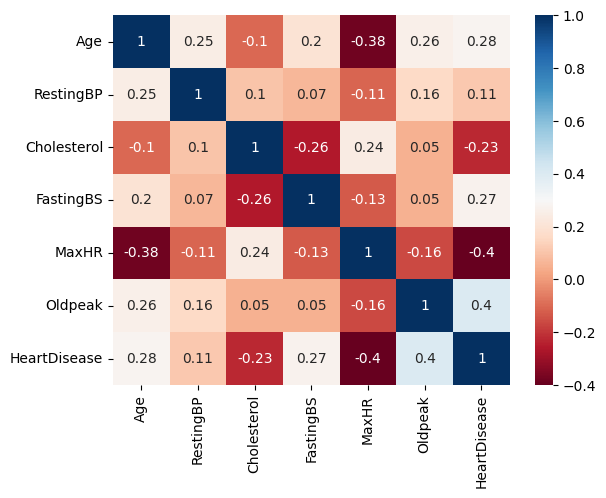

In [11]:
numeric = df.select_dtypes(include='number')

sns.heatmap(numeric.corr().round(2),cmap='RdBu',annot=True)

### 1.4 EDA visualisation of the data ( Numerical features ):

1) **using correlation matrix to plot meaningful data correlation**


In [12]:
corr_matrix = numeric.corr()
corr_matrix

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


In [13]:
# FastingBS (numeric but not continous!)

numeric['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

In [14]:
abs(corr_matrix)>0.2

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,True,True,False,False,True,True,True
RestingBP,True,True,False,False,False,False,False
Cholesterol,False,False,True,True,True,False,True
FastingBS,False,False,True,True,False,False,True
MaxHR,True,False,True,False,True,False,True
Oldpeak,True,False,False,False,False,True,True
HeartDisease,True,False,True,True,True,True,True


In [15]:
# Cholesterol - FastingBS & MaxHR
# FastingBS - MaxHR
# MaxHR - Age

features = ['Cholesterol','MaxHR']

# Check missing values 

numeric['Cholesterol'].value_counts()
# 172 missing values!
numeric['MaxHR'].value_counts()

MaxHR
150    43
140    41
120    36
130    33
160    25
       ..
192     1
195     1
194     1
187     1
202     1
Name: count, Length: 119, dtype: int64

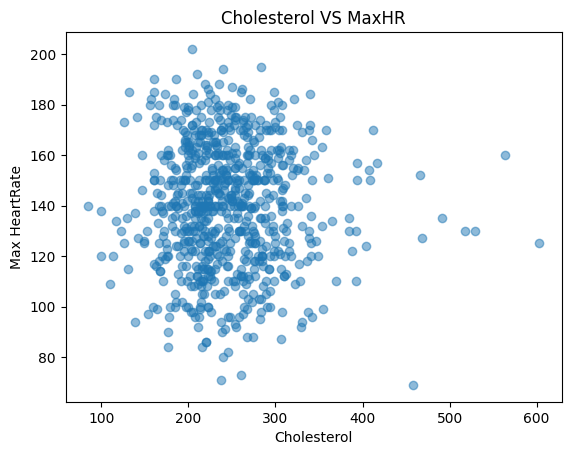

In [16]:
clean_df_plot = numeric[numeric['Cholesterol']>0]
plt.scatter(clean_df_plot['Cholesterol'],clean_df_plot['MaxHR'],alpha=0.5)
plt.xlabel("Cholesterol")
plt.ylabel("Max HeartRate")
plt.title('Cholesterol VS MaxHR')
plt.show()

#### Plot implies that there is no evident relationship between increase in Cholesterol nad Maximum Heart Rate in the patient data

<Axes: xlabel='FastingBS', ylabel='MaxHR'>

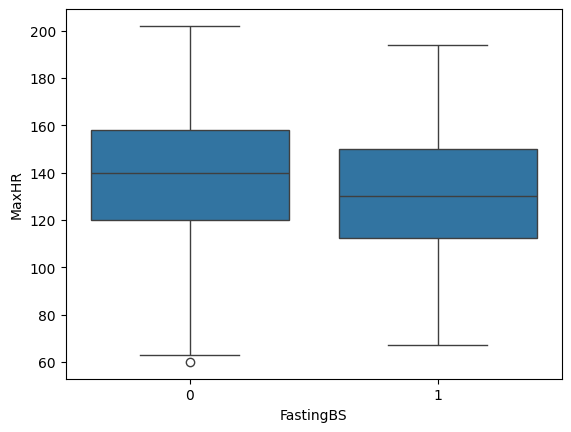

In [17]:
sns.boxplot(data=numeric,x='FastingBS',y='MaxHR')

### Helper function to visualize boxplot of Target/Feature and it's distribution and how it affecets the patient state:

In [18]:
# x axis will be HeartDisease -> target var
# y axis will be other features 
# boxplot 

def plot_boxplot(X):

    x1 = 'HeartDisease'
    features = X.columns[:-1] # exclude target
    n = len(features)
    print(features)
    fig,ax = plt.subplots(1,n,figsize=(10,6))

    for ax,feature in zip(ax.flatten(),features):
        sns.boxplot(data=X,x=x1,y=feature,ax=ax)
        plt.tight_layout()


Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')


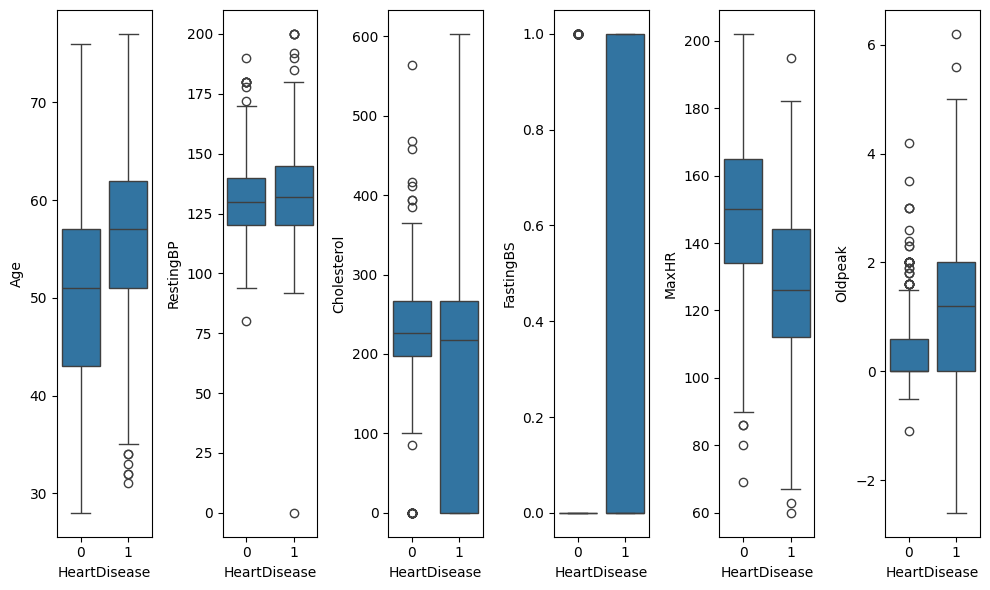

In [19]:
plot_boxplot(numeric)

### Summary of boxplot:

1) Age -> expected behaviour, showing that patients that are older have higher disease incidence, while having some outliers in the lower bound for positive class. From this data and dataset, we do not know anything about history of the patients, their lifestyle and maybe some co-morbidities present.

2) RestingBP -> Median for both classes is similar, while positive class has slighlty higher distribution spread, towrads the higher values of BP. We can not conclude that RestingBP affect the Heart Disease.

3) Cholesterol -> From the boxplot, we may conclude that Cholesterol is not such a good variable for discriminating between postiive and negative class. We need to take into consideration that Cholesterol variable has 170+ missing values, and like this, it's not informative.

4) Fasting Blood Sugar(BS) -> Almost completely evident, that patients with a disease have positive fasting blood glucose higher than 120mg/dl. These patients are considered prediabetic and diabetic. This can also indicate that patients may have additional metabolic diseases and should be taken into consideration

5) Max Heart Rate -> We see that patients with no disease have higher maximum heart rate, which could be explained by the heart capacity to sustain exercise.  Lower max heart rate , and evidently lower mean value, indicate that this variable is informative in prediction task 

6) Oldpeak (Degree of ST segment depression measured on ECG during a **stress test** compared to a baseline at rest) 

- During an exercise, heart works harder to pump blood. If patient has some arterial plaque or calcification, they cannot supply enoguh bloodflow

- This shortage causes downward shift (depression) in the ECG ST segment

- downward shift >= 1.5-2 is implying significant indicator of coronar artery disease. 

<Axes: xlabel='MaxHR', ylabel='RestingBP'>

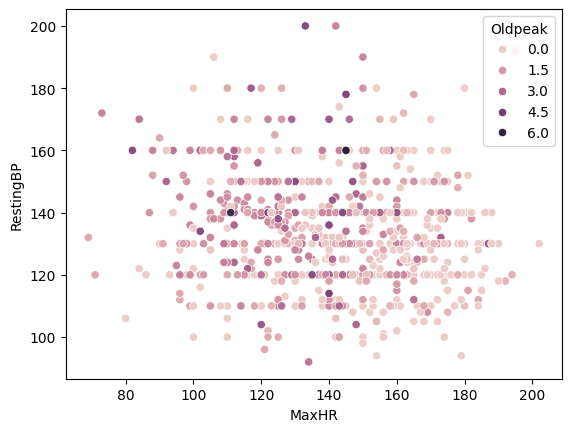

In [20]:
#resting bp , max hr and cholesterol

clean = numeric[(numeric['Cholesterol']>0) & (numeric['Cholesterol']!=np.nan)]

sns.scatterplot(data=clean,x='MaxHR',y='RestingBP',hue='Oldpeak')

### Cholesterol - has missing values. -> Candidate for imputation in the preprocessing

I need to implment correction for these variables

In [21]:
# Cholesterol
# in the original dataset:

df['Cholesterol'] = df['Cholesterol'].replace(0,np.nan)
df['Cholesterol'].isna().sum() # 172 sum values


np.int64(172)

### **1.4 EDA visualisation of the data ( Categorical features )**

In [22]:
# categorical features from dataset

categorical = df.select_dtypes(exclude='number')
categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [23]:
categorical.groupby("RestingECG")['Sex'].describe()

,count,unique,top,freq
RestingECG,,,,
LVH,188,2,M,141
Normal,552,2,M,434
ST,178,2,M,150


In [24]:
categorical.groupby('ExerciseAngina')['RestingECG'].describe()

,count,unique,top,freq
ExerciseAngina,,,,
N,547,3,Normal,345
Y,371,3,Normal,207


In [25]:
categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


### **Preprocessing**

- Train/Test split

- Column Transformer + Pipe

- Missing values imputation

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'X_Train :{X_train.size}')
print(f"X_test:{X_test.size}")


X_Train :8074
X_test:2024


In [27]:
chol = df['Cholesterol'].isna()==True
chol.sum()
z = chol.sum()/len(df)
z # 18% of feature has missing values

df['Cholesterol'].describe()
# mean imputation would be suitable

count    746.000000
mean     244.635389
std       59.153524
min       85.000000
25%      207.250000
50%      237.000000
75%      275.000000
max      603.000000
Name: Cholesterol, dtype: float64

In [28]:
df.isna().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           0
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

In [30]:
for col in categorical.columns:
    print(col,categorical[col].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


**ST_SLOPE** -> Ordinal categories, have rank from mild to worse condition up -> flat -> down

In [31]:
slope_size = categorical['ST_Slope'].unique()
slope_size

array(['Up', 'Flat', 'Down'], dtype=object)

In [32]:
preprocessing = ColumnTransformer(transformers=[
    ('imputer',SimpleImputer(strategy='mean'),['Cholesterol']),
    ('labelEncoder',OrdinalEncoder(),['Sex','ExerciseAngina']),
    ('OrdinalEncoder',OrdinalEncoder(categories=[slope_size]),['ST_Slope']),
    ('Ohe',OneHotEncoder(),['ChestPainType','RestingECG','ExerciseAngina'])],
    remainder='passthrough')

## Preprocessing test on SingleTree

In [33]:
mini_pipe = make_pipeline(
    preprocessing,
    DecisionTreeClassifier()
)

mini_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer', ...), ('labelEncoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.

In [34]:
from sklearn.metrics import precision_score,recall_score,classification_report
y_pred = mini_pipe.predict(X_test)
report = classification_report(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
print(precision)
print(recall)
print(report)

0.8645833333333334
0.7757009345794392
              precision    recall  f1-score   support

           0       0.73      0.83      0.78        77
           1       0.86      0.78      0.82       107

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.81      0.80      0.80       184



## **Modeling** - Baseline with crossvalidation (k=5)

### Models: 

- Single Classification Tree (baseline)

- RandomForest

- XGCBoost

### Scores:

- f1

- precision

- accuracy

- roc_auc

- precision_recall

In [35]:
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import accuracy_score,precision_recall_curve,roc_auc_score,roc_curve,f1_score



In [ ]:
models = {
    'Tree':DecisionTreeClassifier(random_state=42),
    'Forest':RandomForestClassifier(random_state=42),
    'Xboost':XGBClassifier(random_state=42)
}

In [53]:
complete_pipe = {}
for name,model in models.items():
    pipe = make_pipeline(
        preprocessing,
        model
    )
    complete_pipe[name] = pipe

In [38]:
scores = ['f1','accuracy','precision']
def calculate_scores(X,y,pipe,scores,cv,grid = None):
    score_storage = {}
    grid_storage = {}
    for name,model in pipe.items():
        score_storage[name] = {}
        if grid:
            grid_storage[name] = {}
            for name,parameters in grid.items():
                g = GridSearchCV(estimator=model,param_grid=parameters,cv=cv)
                g.fit(X,y)
                best_model = g.best_estimator_
                best_params = g.best_params_
                best_score = g.best_score_
                grid_storage[name]['best'] = best_model
                grid_storage[name]['best_parameters'] = best_params
                grid_storage[name]['best_score'] = best_score
        else:
            for score in scores:
                model.fit(X,y)
                result_score = cross_val_score(estimator = model,X=X,y=y,scoring=score,n_jobs=-1)
                score_storage[name][score] = result_score.mean()
    return score_storage


In [39]:
scores = ['f1','accuracy','precision','recall']
result = calculate_scores(X_train,y_train,complete_pipe,scores,cv=5)
print(result)   

{'Tree': {'f1': np.float64(0.7924476131461249), 'accuracy': np.float64(0.7779983226167179), 'precision': np.float64(0.8085456023574563), 'recall': np.float64(0.7829320987654321)}, 'Forest': {'f1': np.float64(0.8801754339107216), 'accuracy': np.float64(0.8664802907464356), 'precision': np.float64(0.864941227549307), 'recall': np.float64(0.8978086419753086)}, 'Xboost': {'f1': np.float64(0.8714818872334209), 'accuracy': np.float64(0.8569564812226261), 'precision': np.float64(0.8561137899714156), 'recall': np.float64(0.8879012345679012)}}


In [40]:
parameters = {
    'Tree':{'decisiontreeclassifier__max_depth':[1,2,3,4,6,8,16],'decisiontreeclassifier__min_samples_split':[2,4,8,16,32,64,128]},
    'Forest':{'randomforestclassifier__n_estimators':[10,50,100,500],'randomforestclassifier__min_samples_split':[2,4,8,16,32,64,128],'randomforestclassifier__max_depth':[2, 4, 8, 16]},
    'Xboost':{'xgbclassifier__n_estimators':[500],'xgbclassifier__learning_rate':[0.05,0.1,0.2,0.4],'xgbclassifier__subsample':[0.1,0.2,0.5]}
            
}

result_grid = calculate_scores(X_train,y_train,complete_pipe,scores,cv=5,grid=parameters)

ValueError: Invalid parameter 'randomforestclassifier' for estimator Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('imputer', SimpleImputer(),
                                                  ['Cholesterol']),
                                                 ('labelEncoder',
                                                  OrdinalEncoder(),
                                                  ['Sex', 'ExerciseAngina']),
                                                 ('OrdinalEncoder',
                                                  OrdinalEncoder(categories=[array(['Up', 'Flat', 'Down'], dtype=object)]),
                                                  ['ST_Slope']),
                                                 ('Ohe', OneHotEncoder(),
                                                  ['ChestPainType',
                                                   'RestingECG',
           

In [41]:
df_result_baseline = pd.DataFrame(result).T

Pre tuniranja hiperparametara, radim baseline predikcije ovih modela.

In [42]:
df_result_baseline

,f1,accuracy,precision,recall
Tree,0.792448,0.777998,0.808546,0.782932
Forest,0.880175,0.866480,0.864941,0.897809
Xboost,0.871482,0.856956,0.856114,0.887901


In [43]:
df_result_baseline.sort_values(by='f1',ascending=False)

,f1,accuracy,precision,recall
Forest,0.880175,0.866480,0.864941,0.897809
Xboost,0.871482,0.856956,0.856114,0.887901
Tree,0.792448,0.777998,0.808546,0.782932


### Evaluating baseline models, we see that RandomForest has highest scores over these 3 models used

### Hyperparameters:

DT Hyperparameters are external configuration settings used to control the structure, growth, and complexity of a decision tree model. 

Because unconstrained decision trees naturally grow until they completely memorize the training data, tuning these settings is the primary defense 

against __overfitting__.



In [54]:
parameters = {
    'Tree':{'decisiontreeclassifier__max_depth':[1,2,3,4,6,8,16],'decisiontreeclassifier__min_samples_split':[2,4,8,16,32,64,128]},
    'Forest':{'randomforestclassifier__n_estimators':[10,50,100,500],'randomforestclassifier__min_samples_split':[2,4,8,16,32,64,128],'randomforestclassifier__max_depth':[2, 4, 8, 16]},
    'Xboost':{'xgbclassifier__n_estimators':[500],'xgbclassifier__learning_rate':[0.05,0.1,0.2,0.4],'xgbclassifier__verbosity':[1]}
            
}

#### All 3 models defined in the upper cell are tree based, thus they can use initial column_transformer ( same transformations are applied to same columns)

- preprocessing

In [ ]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer', ...), ('labelEncoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

## GridSearchCV

- Class used for exhaustive search for parameters predefined 

- GridSearchCV try all possible combination of parameters:

example: 

max_depth: [2,4,7]
min_samples_leaf: [2,4,8]

**9 times the model is fit**

**While this can be computationally expensive, it's the best method to obtain best parameters in small-medium param. grid size.**

### Alternative: RandomizedSearchCV -> Picks random parameters to train the model **best used for small grids and fast execution**
---
**GridSearchCV**

- estimator

- param_grid: list or list of dicts with parameters 

- scoring

- n_jobs: -1 all cores utilization

- refit: **default: True** -> refits the estimator with best found parameters on the whole dataset

- cv: CV splitting strategy, specify k (number of folds used for test , k - 1 for training)